# **Linear Regression**


Linear Regression is a method to find a relationship between input variables (features) and an output variable (target).

***Importing Basic Libraries***

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

**How can we load it in Python using pandas and see the first few rows?**.

In [2]:
df=pd.read_csv('Food_Delivery_Times.csv')

## Exploring the Data**

Check your dataset by some of the commands to quickly see its size, column names, missing values, and basic statistics.

In [3]:
df.head()

,Order_ID,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
0,522,7.93,Windy,Low,Afternoon,Scooter,12,1.0,43
1,738,16.42,Clear,Medium,Evening,Bike,20,2.0,84
2,741,9.52,Foggy,Low,Night,Scooter,28,1.0,59
3,661,7.44,Rainy,Medium,Afternoon,Scooter,5,1.0,37
4,412,19.03,Clear,Low,Morning,Bike,16,5.0,68


In [4]:
df.shape

(1000, 9)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Order_ID                1000 non-null   int64  
 1   Distance_km             1000 non-null   float64
 2   Weather                 970 non-null    object 
 3   Traffic_Level           970 non-null    object 
 4   Time_of_Day             970 non-null    object 
 5   Vehicle_Type            1000 non-null   object 
 6   Preparation_Time_min    1000 non-null   int64  
 7   Courier_Experience_yrs  970 non-null    float64
 8   Delivery_Time_min       1000 non-null   int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 70.4+ KB


In [6]:
df.describe()

,Order_ID,Distance_km,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
count,1000.000000,1000.000000,1000.000000,970.000000,1000.000000
mean,500.500000,10.059970,16.982000,4.579381,56.732000
std,288.819436,5.696656,7.204553,2.914394,22.070915
min,1.000000,0.590000,5.000000,0.000000,8.000000
25%,250.750000,5.105000,11.000000,2.000000,41.000000
50%,500.500000,10.190000,17.000000,5.000000,55.500000
75%,750.250000,15.017500,23.000000,7.000000,71.000000
max,1000.000000,19.990000,29.000000,9.000000,153.000000


In [7]:
df.isnull().sum()

Order_ID                   0
Distance_km                0
Weather                   30
Traffic_Level             30
Time_of_Day               30
Vehicle_Type               0
Preparation_Time_min       0
Courier_Experience_yrs    30
Delivery_Time_min          0
dtype: int64

### Handling Null Values
Fill the missing values in the categorical columns by replacing them with the most frequent value in each column.

In [8]:
cat_col=['Weather','Traffic_Level','Time_of_Day']

for col in cat_col:
    df[col]=df[col].fillna(df[col].mode()[0])

<Axes: xlabel='Courier_Experience_yrs', ylabel='Count'>

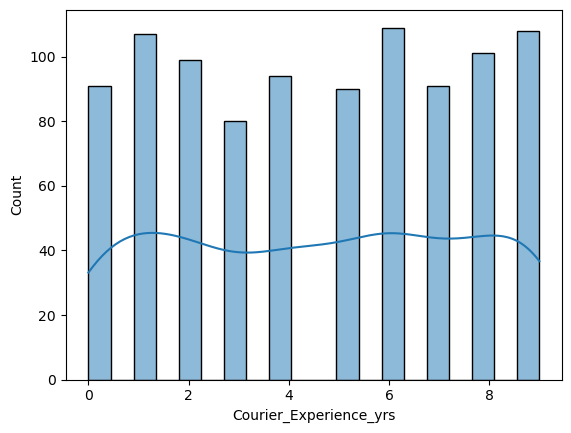

In [9]:
sns.histplot(x='Courier_Experience_yrs',data=df,bins=20,kde=True)

<Axes: xlabel='Courier_Experience_yrs', ylabel='Density'>

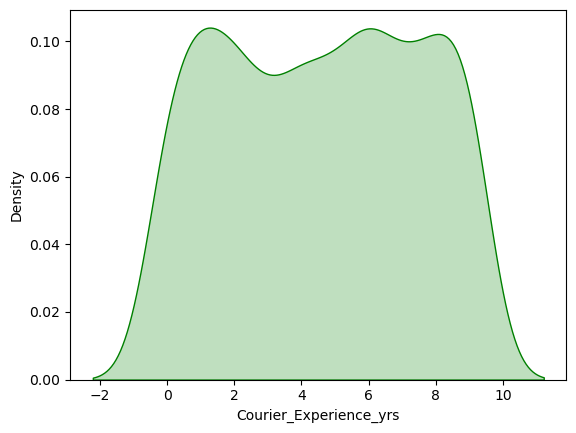

In [10]:
sns.kdeplot(x='Courier_Experience_yrs',data=df,fill=True,color='green')

In [11]:
df['Courier_Experience_yrs']=df['Courier_Experience_yrs'].fillna(df['Courier_Experience_yrs'].median())

In [12]:
df.isnull().sum()

Order_ID                  0
Distance_km               0
Weather                   0
Traffic_Level             0
Time_of_Day               0
Vehicle_Type              0
Preparation_Time_min      0
Courier_Experience_yrs    0
Delivery_Time_min         0
dtype: int64

In [13]:
df.head()

,Order_ID,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
0,522,7.93,Windy,Low,Afternoon,Scooter,12,1.0,43
1,738,16.42,Clear,Medium,Evening,Bike,20,2.0,84
2,741,9.52,Foggy,Low,Night,Scooter,28,1.0,59
3,661,7.44,Rainy,Medium,Afternoon,Scooter,5,1.0,37
4,412,19.03,Clear,Low,Morning,Bike,16,5.0,68


## Visualizing the Data
Visualize the relationships between all pairs of variables in the dataset to see patterns and correlations.

<Axes: xlabel='Delivery_Time_min', ylabel='Count'>

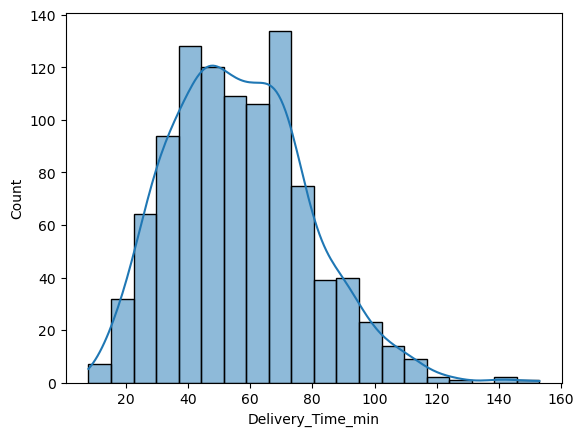

In [14]:
sns.histplot(x='Delivery_Time_min',data=df,bins=20,kde=True)

In [15]:
cat_col=['Weather','Traffic_Level','Time_of_Day','Vehicle_Type']

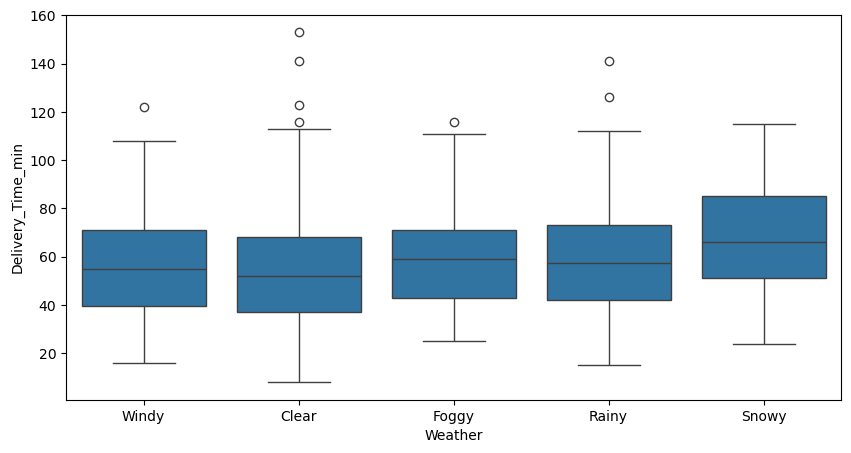

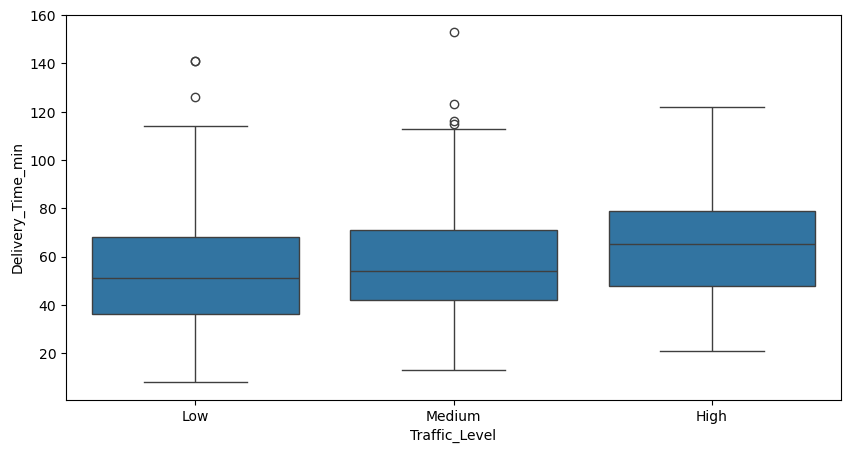

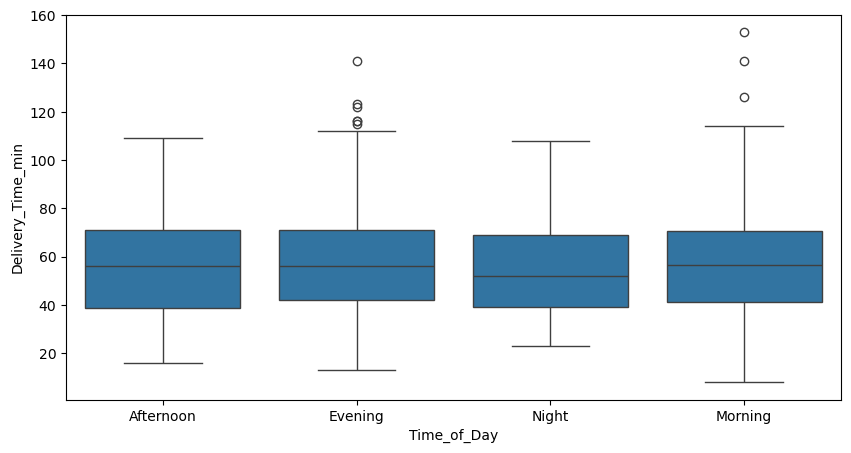

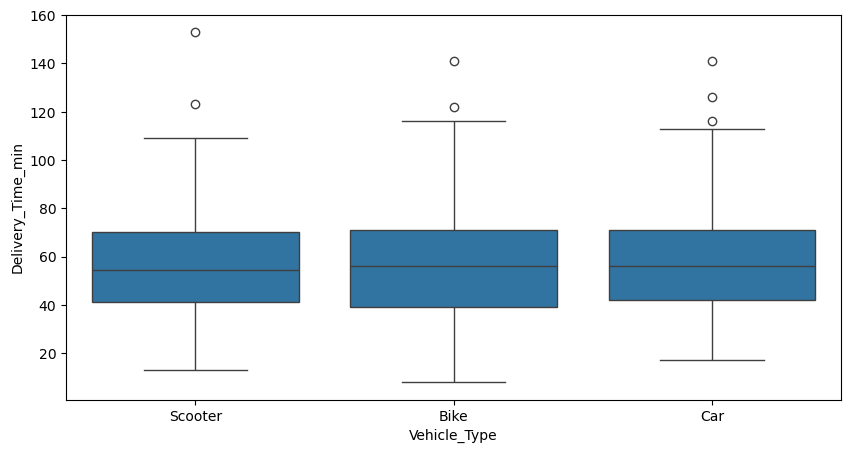

In [16]:
for col in cat_col:
    plt.figure(figsize=(10,5))
    sns.boxplot(x=df[col],y='Delivery_Time_min',data=df)

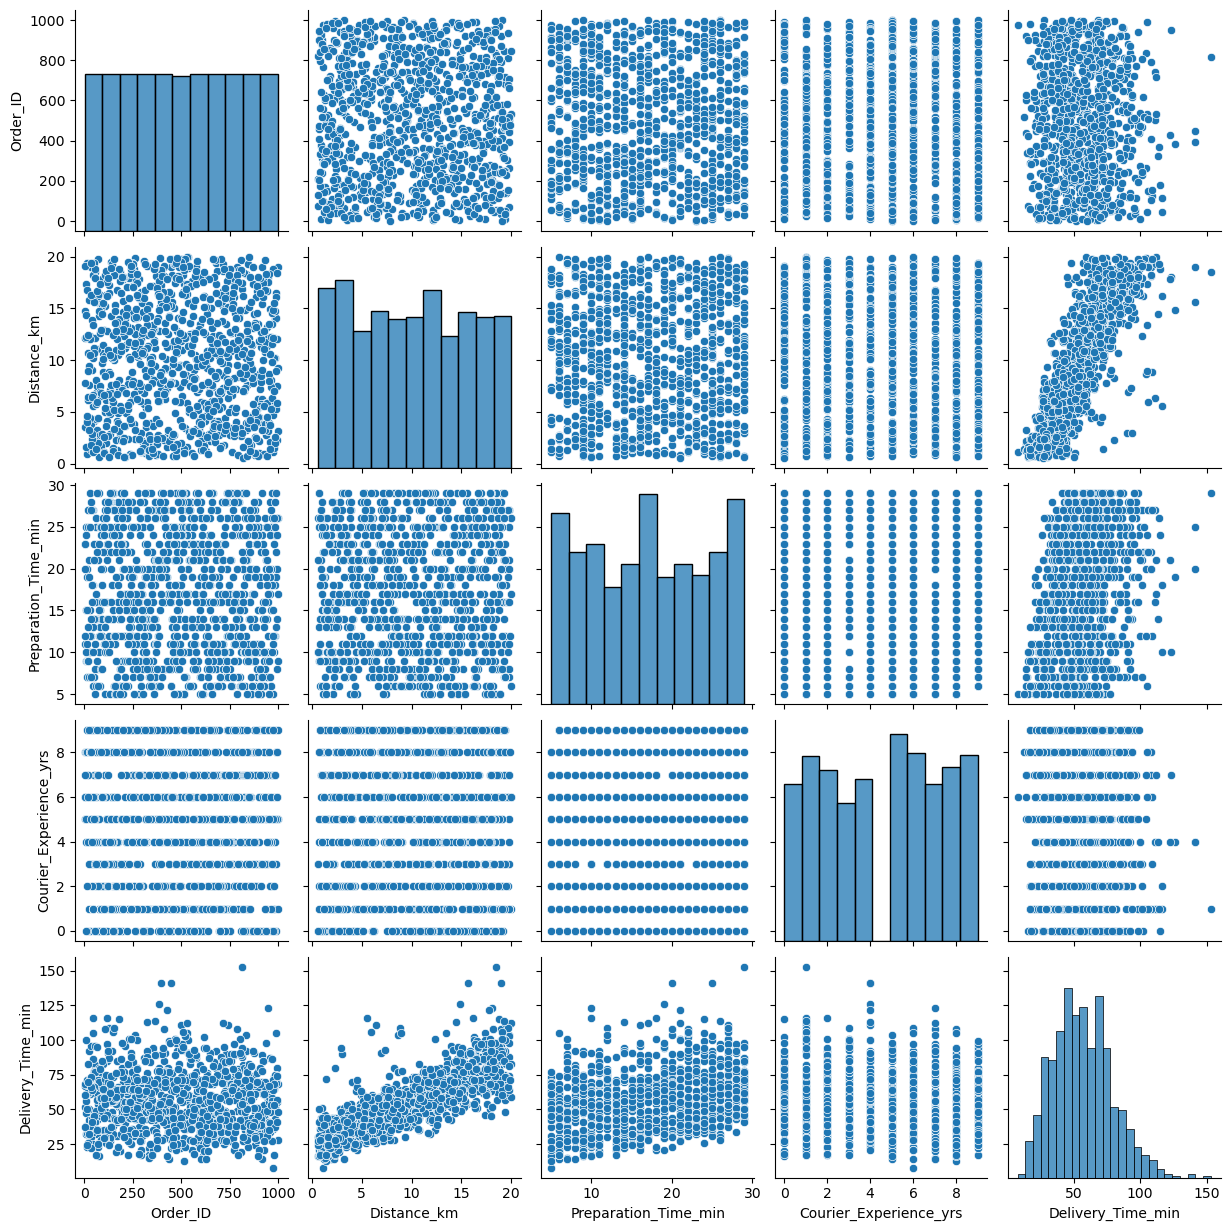

In [17]:
sns.pairplot(df)

### Mapping Values
Linear Regression works only on numeric data, so we need to convert categorical columns into numbers.

In [18]:
for col in cat_col:
    print(df[col].value_counts())

Weather
Clear    500
Rainy    204
Foggy    103
Snowy     97
Windy     96
Name: count, dtype: int64
Traffic_Level
Medium    420
Low       383
High      197
Name: count, dtype: int64
Time_of_Day
Morning      338
Evening      293
Afternoon    284
Night         85
Name: count, dtype: int64
Vehicle_Type
Bike       503
Scooter    302
Car        195
Name: count, dtype: int64


In [19]:
from sklearn.preprocessing import LabelEncoder

In [20]:
encoder=LabelEncoder()

In [21]:
df_copy=df.copy()

In [22]:
for col in cat_col:
    df[col]=encoder.fit_transform(df[col])

In [23]:
df.shape

(1000, 9)

In [24]:
df_dummies=pd.get_dummies(df_copy,columns=cat_col)

In [25]:
df_dummies=df_dummies.astype(float)

In [26]:
df_dummies.head()

,Order_ID,Distance_km,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min,Weather_Clear,Weather_Foggy,Weather_Rainy,Weather_Snowy,Weather_Windy,Traffic_Level_High,Traffic_Level_Low,Traffic_Level_Medium,Time_of_Day_Afternoon,Time_of_Day_Evening,Time_of_Day_Morning,Time_of_Day_Night,Vehicle_Type_Bike,Vehicle_Type_Car,Vehicle_Type_Scooter
0,522.0,7.93,12.0,1.0,43.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
1,738.0,16.42,20.0,2.0,84.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
2,741.0,9.52,28.0,1.0,59.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
3,661.0,7.44,5.0,1.0,37.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
4,412.0,19.03,16.0,5.0,68.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0


## **Defining Features and Target**

X (features) → known factors (distance, traffic, weather, etc.)

y (target) → what we want to predict (delivery time)


In [27]:
x_encoded=df.drop('Delivery_Time_min',axis=1)
y_encoded=df['Delivery_Time_min']

In [28]:
x_dummies=df_dummies.drop(['Delivery_Time_min','Order_ID'],axis=1)
y_dummies=df_dummies['Delivery_Time_min']

In [29]:
x_encoded.head()

,Order_ID,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs
0,522,7.93,4,1,0,2,12,1.0
1,738,16.42,0,2,1,0,20,2.0
2,741,9.52,1,1,3,2,28,1.0
3,661,7.44,2,2,0,2,5,1.0
4,412,19.03,0,1,2,0,16,5.0


## Splitting Data into Train and Test Sets**

How can we check how well our model performs on unseen data?
Why do we split the dataset into two parts:

Training set (80%) → used to train the model

Testing set (20%) → used to evaluate the modelbrary.


In [30]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error,r2_score

In [31]:
x1_train,x1_test,y1_train,y1_test=train_test_split(x_encoded,y_encoded,random_state=42,test_size=0.2)

In [32]:
from sklearn.linear_model import LinearRegression

In [33]:
model_encoded=LinearRegression()

## Training the Linear Regression Model**


In [34]:
model_encoded.fit(x1_train,y1_train)

LinearRegression()

In [35]:
y2_pred=model_encoded.predict(x1_test)

In [36]:
mean_squared_error(y1_test,y2_pred)

109.23986283518467

In [37]:
r2_en=r2_score(y1_test,y2_pred)

In [38]:
r2_en

0.7562844966321256

In [39]:
aj_r2=1-((1-r2_en)*(df.shape[0]-1))/(df.shape[0]-df.shape[1]-1)

In [40]:
aj_r2

0.7540689011469631

In [41]:
x_train,x_test,y_train,y_test=train_test_split(x_dummies,y_dummies,random_state=42,test_size=0.2)

In [42]:
model_dummies=LinearRegression()

In [43]:
model_dummies.fit(x_train,y_train)

LinearRegression()

## Making Predictions

Use the trained model to predict delivery times for the test data.

In [44]:
y_pred=model_dummies.predict(x_test)

## **Evaluating the Model**

Check how accurate your predictions are by calculating the average error, squared error, and R² score.


In [45]:
mean_squared_error(y_test,y_pred)

77.90657530660583

In [46]:
r2=r2_score(y_test,y_pred)

In [47]:
r2

0.8261894538886112

In [48]:
adjusted_r2=1-((1-r2)*(1000-1))/(df_dummies.shape[0]-df_dummies.shape[1]-1)

In [49]:
adjusted_r2

0.8226386766442519

In [50]:
print(f"The r2 value of Label_Encoded Data is {r2_en}")
print(f"The Adjusted r2 value of Label_Encoded Data is {aj_r2}")
print(f"The r2 value of One_Hot_Encoded Data is {r2}")
print(f"The Adjusted r2 value of One_Hot_Encoded Data is {adjusted_r2}")

The r2 value of Label_Encoded Data is 0.7562844966321256
The Adjusted r2 value of Label_Encoded Data is 0.7540689011469631
The r2 value of One_Hot_Encoded Data is 0.8261894538886112
The Adjusted r2 value of One_Hot_Encoded Data is 0.8226386766442519


In [51]:
y_train_pred=model_dummies.predict(x_train)
y_test_pred=model_dummies.predict(x_test)

In [52]:
r2_train=r2_score(y_train,y_train_pred)
r2_test=r2_score(y_test,y_test_pred)

In [53]:
r2_train

0.7630020365990979

In [54]:
r2_test

0.8261894538886112

### **Visualizing Predictions**


Create a scatter plot to compare actual vs predicted delivery times and visually check how well the model is performing.


### Ridge Regression
Train a Ridge regression model on the training data, predict delivery times for the test set, and evaluate its accuracy using MAE, MSE, and R².

In [55]:
from sklearn.linear_model import Ridge,Lasso

In [56]:
ridge=Ridge()

In [57]:
ridge.fit(x_train,y_train)

Ridge()

In [58]:
predi=ridge.predict(x_test)

In [59]:
r2_score(y_test,predi)

0.8260506906056774

### Lasso Regression
Train a Lasso regression model on your training data, predict delivery times for the test set, and check how accurate the predictions are using MAE, MSE, and R².

In [60]:
lasso=Lasso()

In [61]:
lasso.fit(x_train,y_train)

Lasso()

In [62]:
pre=lasso.predict(x_test)

In [63]:
r2_score(y_test,pre)

0.7688930954534523

<Axes: >

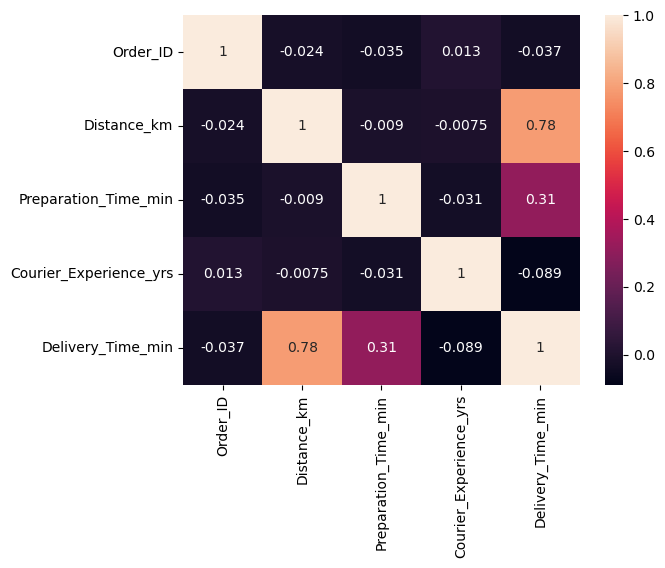

In [64]:
sns.heatmap(df_copy.corr(numeric_only=True),annot=True)

In [65]:
df_copy

,Order_ID,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
0,522,7.93,Windy,Low,Afternoon,Scooter,12,1.0,43
1,738,16.42,Clear,Medium,Evening,Bike,20,2.0,84
2,741,9.52,Foggy,Low,Night,Scooter,28,1.0,59
3,661,7.44,Rainy,Medium,Afternoon,Scooter,5,1.0,37
4,412,19.03,Clear,Low,Morning,Bike,16,5.0,68
...,...,...,...,...,...,...,...,...,...
995,107,8.50,Clear,High,Evening,Car,13,3.0,54
996,271,16.28,Rainy,Low,Morning,Scooter,8,9.0,71
997,861,15.62,Snowy,High,Evening,Scooter,26,2.0,81
998,436,14.17,Clear,Low,Afternoon,Bike,8,0.0,55


In [66]:
df_copy_dummie=pd.get_dummies(df_copy,columns=['Weather','Traffic_Level','Time_of_Day','Vehicle_Type'])

In [67]:
df_copy_dummie=df_copy_dummie.astype(float)

In [68]:
df_copy_feature=df_copy_dummie.drop('Delivery_Time_min',axis=1)
df_copy_label=df_copy_dummie['Delivery_Time_min']

In [69]:
model2=LinearRegression()

In [70]:
x2_train,x2_test,y2_train,y2_test=train_test_split(df_copy_feature,df_copy_label,random_state=42,test_size=0.2)

In [71]:
model2.fit(x2_train,y2_train)

LinearRegression()

In [72]:
new_pre=model2.predict(x2_test)

In [73]:
r=r2_score(y2_test,new_pre)

In [74]:
r

0.825047604216602

In [75]:
adjusted_r2_score=1-((1-r2)*(1000-1))/(df_copy_dummie.shape[0]-df_copy_dummie.shape[1]-1)

In [76]:
adjusted_r2_score

0.8226386766442519

In [77]:
y2_train_pred=model2.predict(x2_train)

In [78]:
y2_test_pred=model2.predict(x2_test)

In [79]:
r_train=r2_score(y2_train,y2_train_pred)

In [80]:
r_test=r2_score(y2_test,y2_test_pred)

In [81]:
r_train

0.7632379185718835

In [82]:
r_test

0.825047604216602

### Polynomial Regression
Transform your features to include polynomial terms, train a Linear Regression model on them, and calculate the mean squared error to see how well the curved model fits your data.

In [83]:
from sklearn.preprocessing import PolynomialFeatures

In [84]:
ploy=PolynomialFeatures(degree=2)

In [85]:
x_train_poly=ploy.fit_transform(x_train)

In [86]:
x_test_ploy=ploy.fit_transform(x_test)

In [87]:
model_poly=LinearRegression()

In [88]:
model_poly.fit(x_train_poly,y_train)

LinearRegression()

In [89]:
y_pred=model_poly.predict(x_test_ploy)

In [90]:
r2_score(y_test,y_pred)

0.7914690378807374

In [92]:
import pickle
# Save model
with open("model_dummies.pkl", "wb") as f:
    pickle.dump(model_dummies, f)

# Save column order
with open("dummy_columns.pkl", "wb") as f:
    pickle.dump(df.columns, f)

In [93]:
X = df_dummies.drop("Delivery_Time_min", axis=1)

with open("dummy_columns.pkl", "wb") as f:
    pickle.dump(X.columns, f)

In [94]:
import pickle

# Drop Order_ID and Target
X = df_dummies.drop(["Delivery_Time_min", "Order_ID"], axis=1)
y = df_dummies["Delivery_Time_min"]

# Train model
model_dummies.fit(X, y)

# Save model
with open("model_dummies.pkl", "wb") as f:
    pickle.dump(model_dummies, f)

# Save correct columns
with open("dummy_columns.pkl", "wb") as f:
    pickle.dump(X.columns, f)

print("Model retrained and saved correctly!")


Model retrained and saved correctly!


# Conclusion
-Predicted food delivery times using features like distance, traffic, weather, time, and courier experience.

-Applied Linear Regression for basic predictions.

-Used Ridge and Lasso to reduce overfitting and improve accuracy.

-Explored Polynomial Regression to capture nonlinear relationships.

-Evaluated models with MAE, MSE, and R² to measure performance.

-Demonstrated a real-world application of regression in optimizing delivery operations.